In [20]:
# Import necessary libraries

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional , LSTM , Embedding , Dense , Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

#  Load the dataset

# The dataset is a TSV (tab-separated values) file
file_path = '/content/amazon_alexa.tsv'

df = pd.read_csv(file_path, delimiter='\t')

# Explore the data (optional)
print(df.head())


print(df.isna().sum())

#  Data Preprocessing




   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


In [12]:
# from google.colab import files
# uploaded = files.upload()  # Upload amazon_alexa.tsv again


In [13]:
# Drop columns not needed for sentiment analysis
df.drop(columns=['date', 'variation', 'feedback'], inplace=True)



In [14]:

# Convert ratings to binary sentiment labels:
# Ratings 1, 2, 3 => 0 (negative/neutral)
# Ratings 4, 5 => 1 (positive)
def sentiment_rating(rating):
    if int(rating) <= 3:
        return 0
    else:
        return 1

df['rating'] = df['rating'].apply(sentiment_rating)

# Rename columns for clarity
df.columns = ['Liked', 'Review']

# Check the distribution of labels
print("\nLabel distribution:")
print(df['Liked'].value_counts())


Label distribution:
Liked
1    2741
0     409
Name: count, dtype: int64


In [15]:
#  Prepare features and labels

# X = reviews as strings (text data)
X = df['Review'].astype(str)

# y = sentiment labels (0 or 1)
y = df['Liked']

#  Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

In [22]:
#  Tokenize and pad sequences

vocab_size = 1000  # Use top 1000 words in vocabulary
max_length = 500   # Max length of each review sequence

# Create tokenizer and fit on training text only
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform length
padded_train = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
padded_test = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

#  Build the deep learning model

model = Sequential()

model.add(Input(shape=(max_length,)))  # Define input shape explicitly here

# Embedding layer: converts integer tokens to dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=1000))
                    #,input_shape=(max_length,)))

# Bidirectional LSTM layer to capture context from both directions
model.add(Bidirectional(LSTM(units=32)))

# Fully connected layers for classification
model.add(Dense(128, activation='relu'))
model.add(Dense(128, activation='relu'))

# Output layer with sigmoid activation for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model with Adam optimizer and binary crossentropy loss
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [23]:
#  Model summary (optional)
print("\nModel Summary:")
model.summary()

#  Train the model

history = model.fit(
    padded_train, y_train,
    validation_data=(padded_test, y_test),
    epochs=10,
    batch_size=32
)


Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 500, 1000)      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │       264,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,289,409 (4.92 MB)

 Trainable params: 1,289,409 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8285 - loss: 0.4167 - val_accuracy: 0.8873 - val_loss: 0.2610
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9312 - loss: 0.1717 - val_accuracy: 0.8968 - val_loss: 0.2358
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9502 - loss: 0.1154 - val_accuracy: 0.8921 - val_loss: 0.3104
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9536 - loss: 0.0953 - val_accuracy: 0.9000 - val_loss: 0.2939
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9736 - loss: 0.0620 - val_accuracy: 0.8968 - val_loss: 0.4159
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9865 - loss: 0.0363 - val_accuracy: 0.9032 - val_loss: 0.3773
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9830 - loss: 0.0352 - val_accuracy: 0.8984 - val_loss: 0.4369
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9883 - loss: 0.0211 - val_accuracy: 0.9000 - v

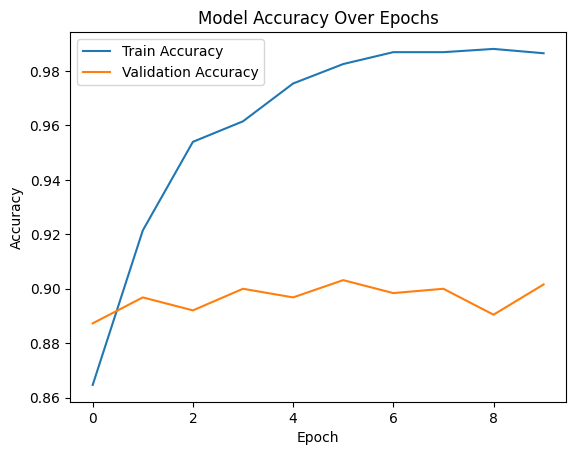

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8820 - loss: 0.6908

Test Loss: 0.5496
Test Accuracy: 0.9016


In [24]:
# Plot training and validation accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model on test data

loss, accuracy = model.evaluate(padded_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
